In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2
from matplotlib.patches import Ellipse

np.random.seed(12345)

In [57]:
def pearson_corr(x, y):
    return np.corrcoef(x, y)[0, 1]

def spearman_corr(x, y):
    return stats.spearmanr(x, y)[0]

def quadrant_corr(x, y):
    med_x = np.median(x)
    med_y = np.median(y)
    x_shifted = x - med_x
    y_shifted = y - med_y
    n1 = np.sum((x_shifted > 0) & (y_shifted > 0))
    n2 = np.sum((x_shifted < 0) & (y_shifted > 0))
    n3 = np.sum((x_shifted < 0) & (y_shifted < 0))
    n4 = np.sum((x_shifted > 0) & (y_shifted < 0))
    n = len(x)
    return (n1 + n3 - n2 - n4) / n

In [59]:
def generate_bivariate_normal(n, rho):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    sample = np.random.multivariate_normal(mean, cov, n)
    return sample[:, 0], sample[:, 1]

def generate_mixture(n):
    n_main = int(0.9 * n)
    x_main, y_main = generate_bivariate_normal(n_main, 0.9)
    n_outlier = n - n_main
    x_out, y_out = generate_bivariate_normal(n_outlier, -0.9)
    x_out = x_out * np.sqrt(10)
    y_out = y_out * np.sqrt(10)
    x = np.concatenate([x_main, x_out])
    y = np.concatenate([y_main, y_out])
    return x, y

In [61]:
def add_ellipse(ax, x, y, color):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    cov = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    chi2_val = chi2.ppf(0.95, 2)
    width = 2 * np.sqrt(chi2_val * eigenvalues[0])
    height = 2 * np.sqrt(chi2_val * eigenvalues[1])
    ellipse = Ellipse(xy=(mean_x, mean_y), width=width, height=height, angle=angle, 
                      fill=False, edgecolor=color, linewidth=2, linestyle='--')
    ax.add_patch(ellipse)

In [63]:
def run_experiment(generator, n, n_iterations=1000):
    pearson_vals = []
    spearman_vals = []
    quadrant_vals = []
    for _ in range(n_iterations):
        x, y = generator(n)
        pearson_vals.append(pearson_corr(x, y))
        spearman_vals.append(spearman_corr(x, y))
        quadrant_vals.append(quadrant_corr(x, y))
    return {
        'pearson': {'mean': np.mean(pearson_vals), 'var': np.var(pearson_vals)},
        'spearman': {'mean': np.mean(spearman_vals), 'var': np.var(spearman_vals)},
        'quadrant': {'mean': np.mean(quadrant_vals), 'var': np.var(quadrant_vals)}
    }

In [65]:
sizes = [20, 60, 100]
n_iterations = 1000

experiments = [
    ("Нормальное ρ = 0", lambda n: generate_bivariate_normal(n, 0), 0),
    ("Нормальное ρ = 0.5", lambda n: generate_bivariate_normal(n, 0.5), 0.5),
    ("Нормальное ρ = 0.9", lambda n: generate_bivariate_normal(n, 0.9), 0.9),
    ("Смесь", lambda n: generate_mixture(n), None)
]

results = {}

for name, generator, true_rho in experiments:
    print(f"\n{name}")
    results[name] = {'true_rho': true_rho}
    for n in sizes:
        print(f"  n = {n}")
        results[name][n] = run_experiment(generator, n, n_iterations)


Нормальное ρ = 0
  n = 20
  n = 60
  n = 100

Нормальное ρ = 0.5
  n = 20
  n = 60
  n = 100

Нормальное ρ = 0.9
  n = 20
  n = 60
  n = 100

Смесь
  n = 20
  n = 60
  n = 100


In [71]:
print("\nСРЕДНИЕ ЗНАЧЕНИЯ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ")
print("="*80)
for name in results:
    print(f"\n{name}")
    if results[name]['true_rho'] is not None:
        print(f"Истинное ρ = {results[name]['true_rho']}")
    print(f"{'Коэффициент':<15} {'n=20':>12} {'n=60':>12} {'n=100':>12}")
    print("-"*50)
    for corr_name in ['pearson', 'spearman', 'quadrant']:
        line = f"{corr_name.capitalize():<15}"
        for n in sizes:
            line += f"{results[name][n][corr_name]['mean']:>12.4f}"
        print(line)

print("\nДИСПЕРСИИ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ")
print("="*80)
for name in results:
    print(f"\n{name}")
    print(f"{'Коэффициент':<15} {'n=20':>10} {'n=60':>10} {'n=100':>10}")
    print("-"*50)
    for corr_name in ['pearson', 'spearman', 'quadrant']:
        line = f"{corr_name.capitalize():<15}"
        for n in sizes:
            line += f"{results[name][n][corr_name]['var']:>12.6f}"
        print(line)


СРЕДНИЕ ЗНАЧЕНИЯ КОЭФФИЦИЕНТОВ КОРРЕЛЯЦИИ

Нормальное ρ = 0
Истинное ρ = 0
Коэффициент             n=20         n=60        n=100
--------------------------------------------------
Pearson              0.0033     -0.0002     -0.0048
Spearman             0.0050      0.0011     -0.0051
Quadrant             0.0112      0.0009     -0.0012

Нормальное ρ = 0.5
Истинное ρ = 0.5
Коэффициент             n=20         n=60        n=100
--------------------------------------------------
Pearson              0.4963      0.4919      0.4970
Spearman             0.4608      0.4726      0.4767
Quadrant             0.3150      0.3329      0.3301

Нормальное ρ = 0.9
Истинное ρ = 0.9
Коэффициент             n=20         n=60        n=100
--------------------------------------------------
Pearson              0.8944      0.8981      0.8997
Spearman             0.8630      0.8826      0.8867
Quadrant             0.6860      0.7043      0.7094

Смесь
Коэффициент             n=20         n=60        n=100
--

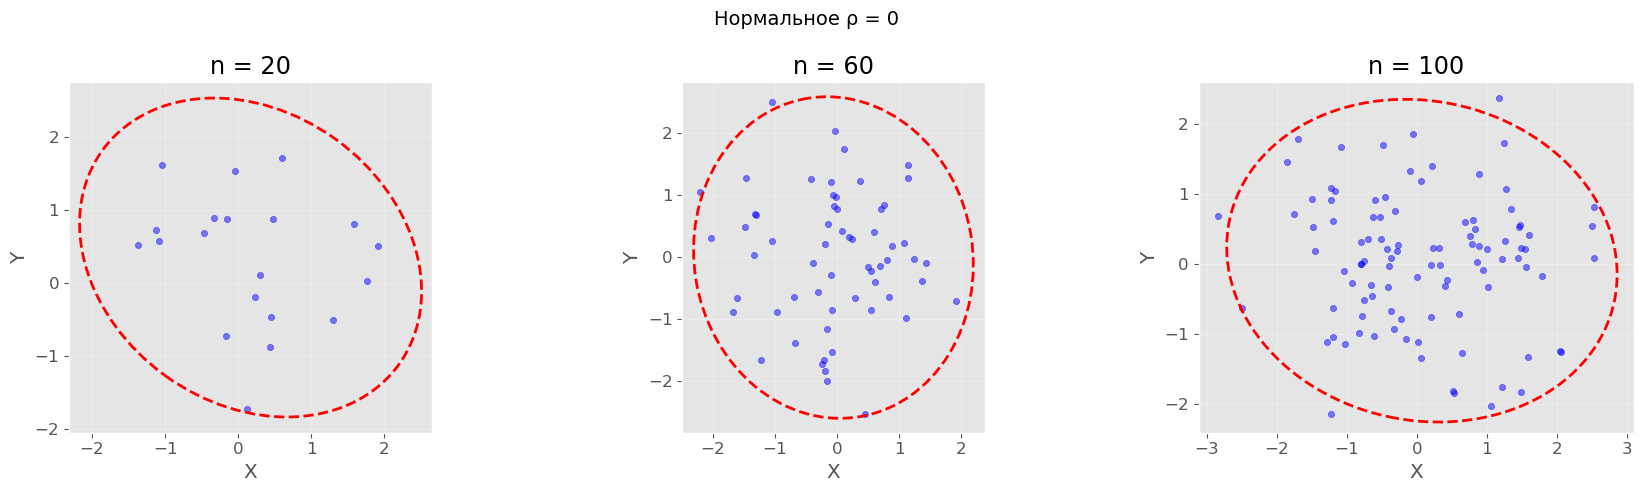

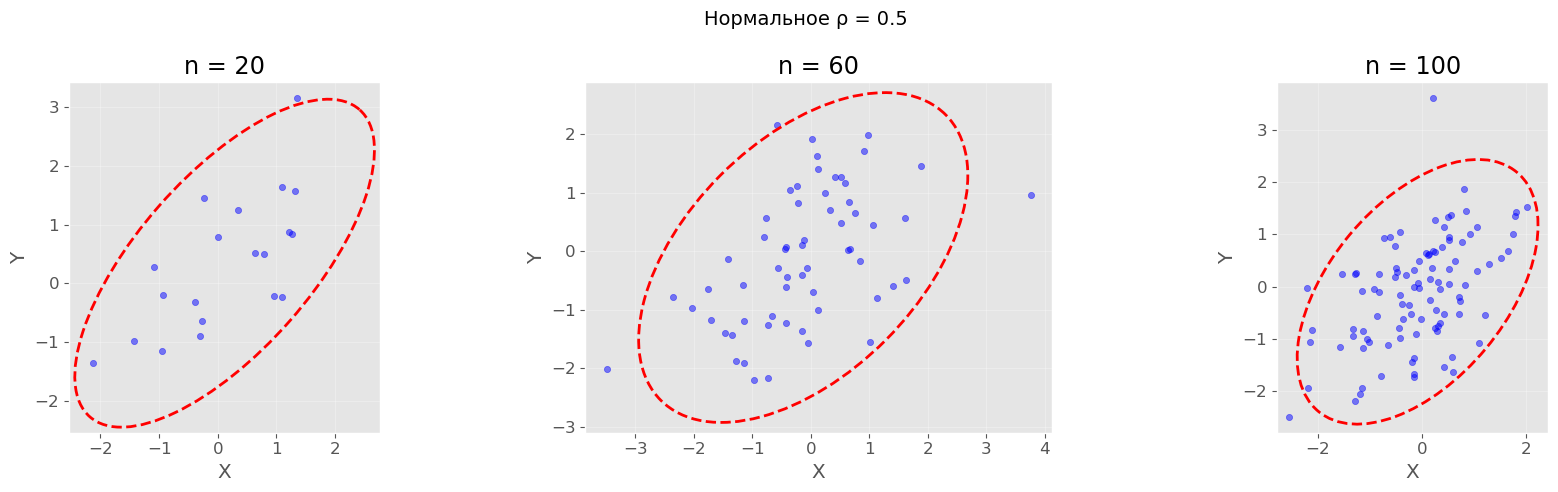

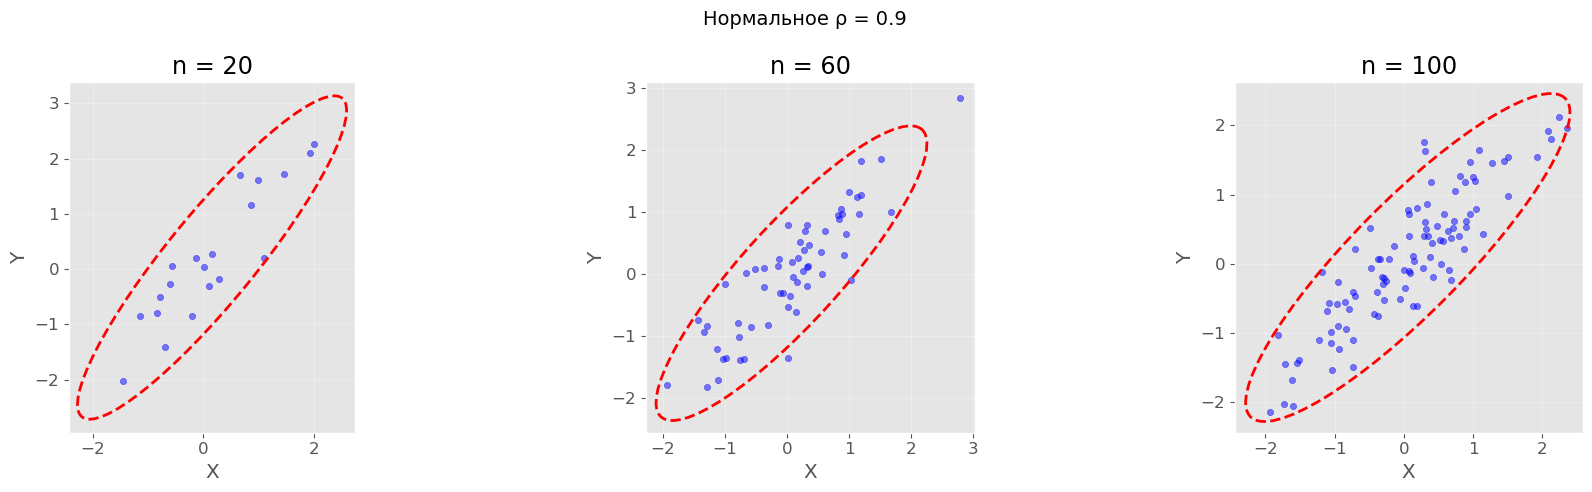

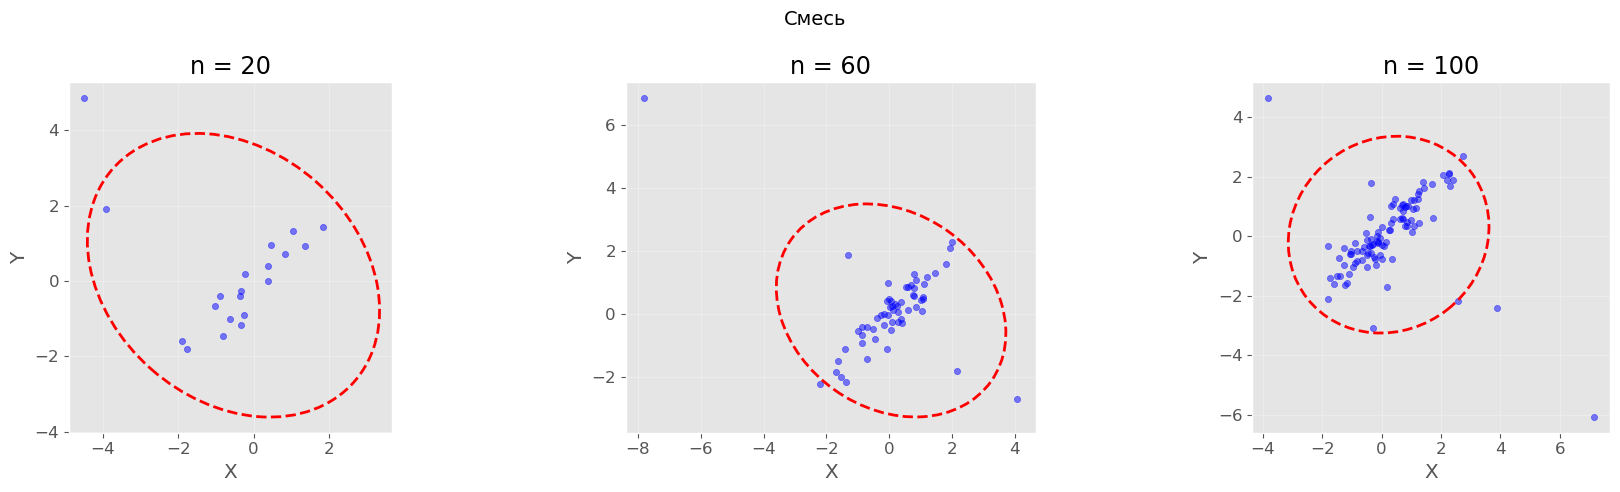

In [73]:
for name, generator, true_rho in experiments:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{name}', fontsize=14)
    for idx, n in enumerate(sizes):
        ax = axes[idx]
        x, y = generator(n)
        ax.scatter(x, y, alpha=0.5, s=20, color='blue')
        add_ellipse(ax, x, y, 'red')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f'n = {n}')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

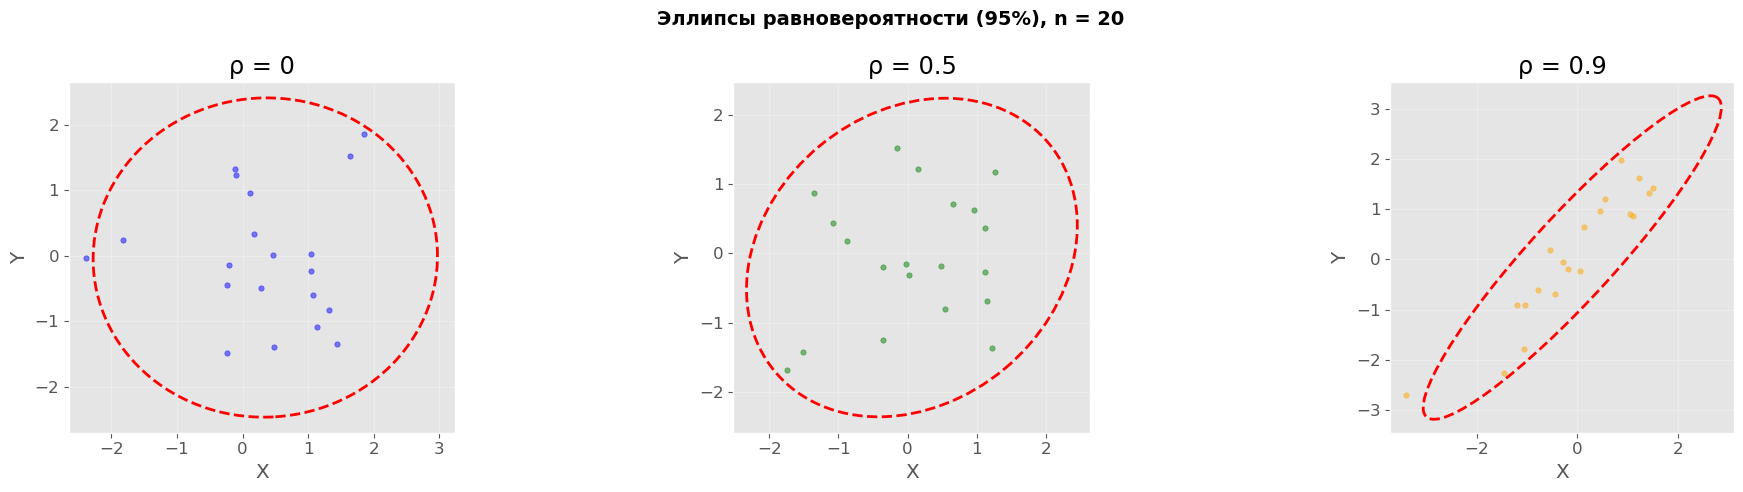

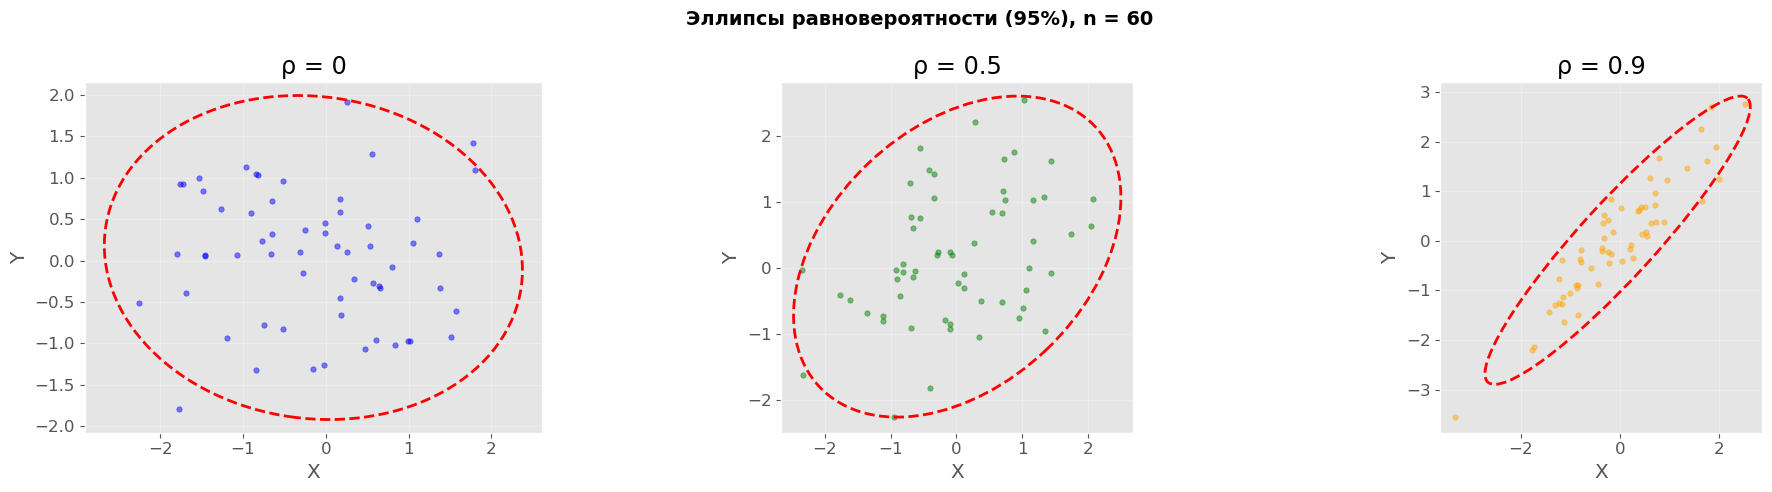

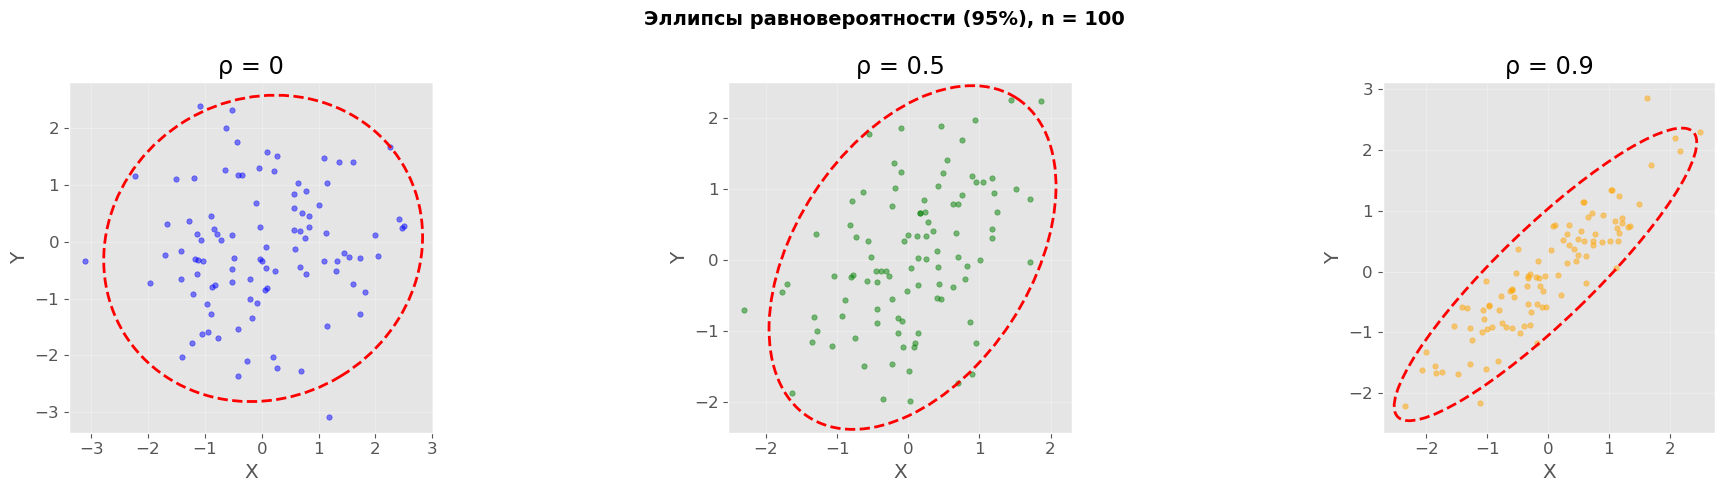

In [81]:
n_values = [20, 60, 100]

for n in n_values:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Эллипсы равновероятности (95%), n = {n}', fontsize=14, fontweight='bold')
    
    # Нормальное ρ = 0
    ax = axes[0]
    x, y = generate_bivariate_normal(n, 0)
    ax.scatter(x, y, alpha=0.5, s=15, color='blue')
    add_ellipse(ax, x, y, 'red')
    ax.set_title('ρ = 0')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Нормальное ρ = 0.5
    ax = axes[1]
    x, y = generate_bivariate_normal(n, 0.5)
    ax.scatter(x, y, alpha=0.5, s=15, color='green')
    add_ellipse(ax, x, y, 'red')
    ax.set_title('ρ = 0.5')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Нормальное ρ = 0.9
    ax = axes[2]
    x, y = generate_bivariate_normal(n, 0.9)
    ax.scatter(x, y, alpha=0.5, s=15, color='orange')
    add_ellipse(ax, x, y, 'red')
    ax.set_title('ρ = 0.9')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()